In [6]:
from statsmodels.tsa.seasonal import STL
import pandas as pd
import numpy as np

df=pd.read_csv('co2_mm_mlo.csv',comment='#')
df=df.replace([-1,-9.99,-0.99],np.nan)
df.describe()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
count,819.000000,819.000000,819.000000,819.000000,819.000000,624.000000,623.000000,625.000000
mean,1991.792430,6.490842,1992.291067,361.111319,361.100977,25.464744,0.509037,0.194672
std,19.716844,3.451494,19.714900,33.262302,33.195547,4.121202,0.201507,0.081500
min,1958.000000,1.000000,1958.202700,312.420000,314.440000,2.000000,0.150000,0.000000
25%,1975.000000,3.500000,1975.250000,331.175000,330.845000,24.000000,0.360000,0.140000
50%,1992.000000,6.000000,1992.291700,356.300000,356.470000,26.000000,0.480000,0.180000
75%,2009.000000,9.000000,2009.333350,387.380000,387.350000,28.000000,0.620000,0.230000
max,2026.000000,12.000000,2026.375000,432.340000,429.140000,31.000000,1.310000,0.580000


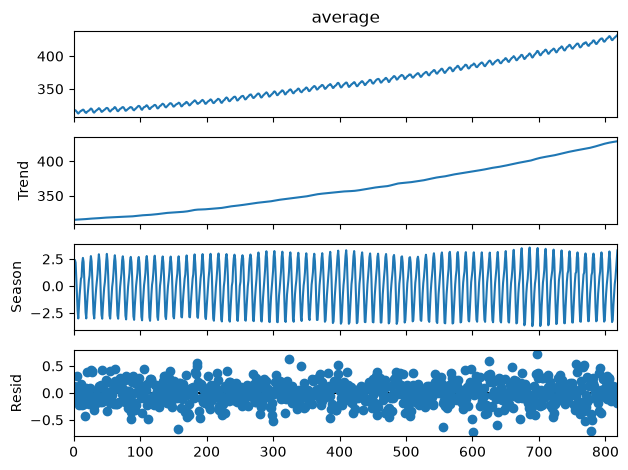

0.06786566462646156


In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

stl=STL(df['average'],period=12)
result=stl.fit()
result.plot()
plt.show()

stat, p = stats.normaltest(result.resid.dropna())   #正規性検定
print(p)


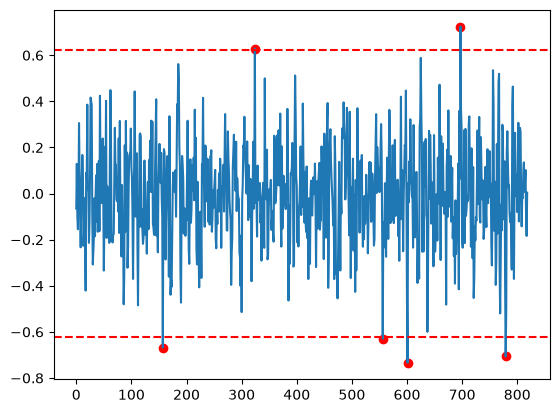

In [ ]:
threshold=result.resid.std()*3
anm=abs(result.resid)>threshold
anm[anm==True]
plt.scatter(anm[anm].index,result.resid[anm],color='red')
plt.plot(result.resid)
plt.axhline(y=threshold, color='red', linestyle='--')
plt.axhline(y=-threshold, color='red', linestyle='--')

# plt.xlabel / plt.ylabel / plt.title — ラベル・タイトル
# plt.legend — 凡例
# plt.figure(figsize=) — サイズ指定

